## 03.02 Detección de Concept Drift y Feature Drift

In [9]:
# Instalamos las librerías necesarias
!pip install pandas scikit-learn alibi-detect matplotlib

Defaulting to user installation because normal site-packages is not writeable


In [10]:
# Importamos las librerías
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import accuracy_score

In [11]:
# Cargamos los datos de entrenamiento
df_train = pd.read_csv("credit-approval-training-data.csv")
df_train.head()

,APPLICANT_ID,AGE_RANGE,INCOME_CATEGORY,RACE,CREDIT_RATING,APPROVED
0,1,3,4,2,6,0
1,2,3,4,3,5,0
2,3,2,3,4,6,0
3,4,2,2,5,6,0
4,5,1,4,4,5,0


In [12]:
# Separamos variables predictoras (X) y variable objetivo (y)
X = df_train[["AGE_RANGE", "INCOME_CATEGORY", "RACE", "CREDIT_RATING"]]
y = df_train["APPROVED"]

# Dividimos en conjunto de entrenamiento (70%) y prueba (30%)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.30, random_state=42)

print("Train:", X_train.shape, "  Test:", X_test.shape)

Train: (700, 4)   Test: (300, 4)


In [13]:
# Entrenamos un modelo Naive Bayes
# GaussianNB asume que cada variable sigue una distribución normal
modelo = GaussianNB()
modelo.fit(X_train, y_train)

# Evaluamos en el conjunto de prueba
y_pred = modelo.predict(X_test)
print(f"Accuracy en prueba: {accuracy_score(y_test, y_pred):.3f}")

Accuracy en prueba: 0.933


In [14]:
# Cargamos los datos de producción (datos reales recibidos después del despliegue)
df_prod = pd.read_csv("credit-approval-prod-data.csv")

X_prod = df_prod[["AGE_RANGE", "INCOME_CATEGORY", "RACE", "CREDIT_RATING"]]
y_prod = df_prod["APPROVED"]

# Aplicamos el modelo entrenado a los datos de producción
y_pred_prod = modelo.predict(X_prod)
print(f"Accuracy en producción: {accuracy_score(y_prod, y_pred_prod):.3f}")

Accuracy en producción: 0.371


### ¿Qué es el Concept Drift?

El **concept drift** ocurre cuando la relación entre las variables de entrada y la variable objetivo cambia con el tiempo.  
En este caso, el modelo tiene un 95% de accuracy en prueba pero solo un 38% en producción.  
Esa caída tan grande es una señal clara de que algo ha cambiado en los datos reales.

In [15]:
# Comparamos la correlación de cada variable con APPROVED
# en entrenamiento vs producción para detectar qué cambió
corr_train = df_train.corr()["APPROVED"][["AGE_RANGE", "INCOME_CATEGORY", "RACE", "CREDIT_RATING"]]
corr_prod  = df_prod.corr()["APPROVED"][["AGE_RANGE", "INCOME_CATEGORY", "RACE", "CREDIT_RATING"]]

df_corr = pd.DataFrame({"ENTRENAMIENTO": corr_train, "PRODUCCION": corr_prod})
df_corr["CAMBIO_%"] = ((df_corr["ENTRENAMIENTO"] - df_corr["PRODUCCION"]) / df_corr["ENTRENAMIENTO"] * 100).round(1)

print(df_corr.round(3))

                 ENTRENAMIENTO  PRODUCCION  CAMBIO_%
AGE_RANGE               -0.036      -0.027      25.6
INCOME_CATEGORY         -0.012      -0.011       1.4
RACE                     0.482       0.464       3.8
CREDIT_RATING           -0.676       0.526     177.8


### 03.04 Detección de Feature Drift

El **feature drift** ocurre cuando la distribución de las variables de entrada cambia entre entrenamiento y producción.  
Lo detectamos comparando visualmente los histogramas y usando el test estadístico Chi-cuadrado.

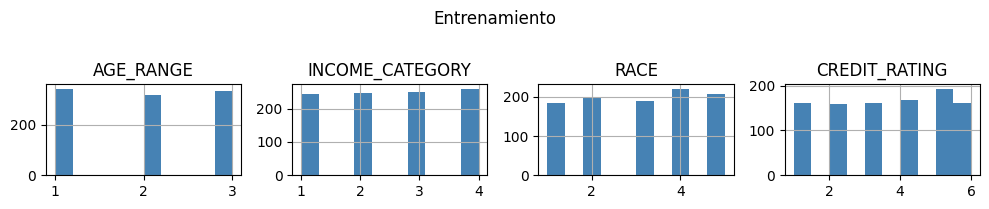

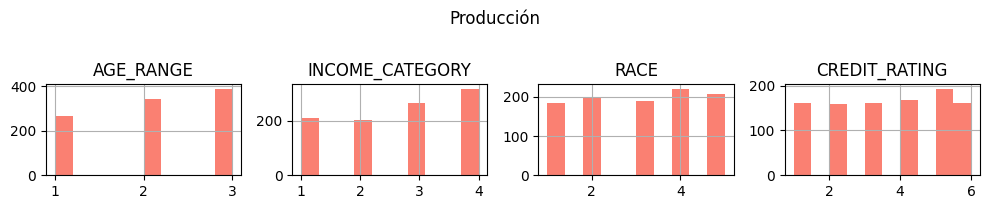

In [16]:
# Comparamos la distribución de cada variable entre entrenamiento y producción
# Azul = entrenamiento  /  Naranja = producción
X.hist(color="steelblue", figsize=(10, 2), layout=(1, 4))
plt.suptitle("Entrenamiento", y=1.02)
plt.tight_layout()
plt.show()

X_prod.hist(color="salmon", figsize=(10, 2), layout=(1, 4))
plt.suptitle("Producción", y=1.02)
plt.tight_layout()
plt.show()

In [17]:
from alibi_detect.cd import ChiSquareDrift

# Inicializamos el detector con los datos de entrenamiento como referencia
# p_val=0.05 es el umbral: si el p-valor es menor, hay drift
detector = ChiSquareDrift(X.to_numpy(), p_val=0.05)

# Comparamos con los datos de producción
resultado = detector.predict(X_prod.to_numpy())

# Mostramos el resultado por variable
for i, col in enumerate(X.columns):
    p_val   = resultado['data']['p_val'][i]
    umbral  = resultado['data']['threshold']
    hay_drift = p_val < umbral
    print(f"{col:20s} | Drift: {'SÍ' if hay_drift else 'NO':3s} | p-valor: {p_val:.3f}")

AGE_RANGE            | Drift: SÍ  | p-valor: 0.001
INCOME_CATEGORY      | Drift: SÍ  | p-valor: 0.005
RACE                 | Drift: NO  | p-valor: 1.000
CREDIT_RATING        | Drift: NO  | p-valor: 1.000
